In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "metabric_clinical_data.tsv"

df_raw = pd.read_csv(DATA_PATH, sep="\t")

TIME_COL = "Overall Survival (Months)"
STATUS_COL = "Overall Survival Status"

In [3]:
df_raw[TIME_COL] = (
    df_raw[TIME_COL]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_raw[TIME_COL] = pd.to_numeric(df_raw[TIME_COL], errors="coerce")

s = df_raw[STATUS_COL].astype(str).str.upper()

df_raw["event"] = np.where(
    s.str.startswith("1:"), 1,
    np.where(s.str.startswith("0:"), 0, np.nan)
)

df = df_raw.dropna(subset=[TIME_COL, "event"]).copy()
df = df[df[TIME_COL] > 0]

df[TIME_COL] = df[TIME_COL].astype(float)
df["event"] = df["event"].astype(int)

df.shape, df["event"].value_counts()

((1980, 40),
 event
 1    1144
 0     836
 Name: count, dtype: int64)

# Cox Features + Cox Model

In [4]:
cox_features = [
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Tumor Stage",
    "ER Status",
    "PR Status",
    "HER2 Status",
    "Chemotherapy",
    "Hormone Therapy",
    "Radio Therapy",
    "Neoplasm Histologic Grade",
]

In [5]:
model_df = df[[TIME_COL, "event"] + cox_features].copy()

num_cols = [
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Tumor Stage",
]

for c in num_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.dropna()

In [6]:
cat_cols = [
    c for c in cox_features
    if c not in num_cols
]

model_df = pd.get_dummies(
    model_df,
    columns=cat_cols,
    drop_first=True
)

In [7]:
for c in num_cols:
    model_df[c] = (
        model_df[c] - model_df[c].mean()
    ) / (model_df[c].std() + 1e-9)

In [8]:
cph = CoxPHFitter(penalizer=0.1)  # mild regularization
cph.fit(
    model_df,
    duration_col=TIME_COL,
    event_col="event"
)

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1354 total observations, 596 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1354
number of events observed = 758
   partial log-likelihood = -4805.50
         time fit was run = 2026-01-16 01:24:01 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
Age at Diagnosis               0.40      1.48      0.04            0.32            0.47                1.37                1.61
Tumor Size                     0.12      1.12      0.03            0.05            0.18                1.06                1.19
Lymph nodes examined positive  0.21      1.23      0.03            0.14            0.28                1.15                1.32
Tumor Stage                    0.15      1.16      0.04            0.07            0.23                1.07                1.25
ER Status_Positive            -0.14      0.87      0.10           -0.34            0.06                0.71                1.06
PR Status_Positive            -0.03      0.97      0.08           -0.18            0.12                0.83                1.12
HER2 Status_Positive           0.31      1.36      0.10            0.10            0.51                1.11                1.67
Chemotherapy_YES               0.09      1.09      0.10           -0.12            0.29                0.89                1.34
Hormone Therapy_YES           -0.09      0.92      0.08           -0.24            0.06                0.79                1.07
Radio Therapy_YES             -0.20      0.82      0.07           -0.34           -0.06                0.71                0.94
Neoplasm Histologic Grade_2.0  0.03      1.03      0.10           -0.17            0.23                0.85                1.26
Neoplasm Histologic Grade_3.0  0.14      1.15      0.10           -0.06            0.34                0.95                1.41

                               cmp to     z      p  -log2(p)
covariate                                                   
Age at Diagnosis                 0.00  9.78 <0.005     72.61
Tumor Size                       0.00  3.73 <0.005     12.36
Lymph nodes examined positive    0.00  6.04 <0.005     29.31
Tumor Stage                      0.00  3.68 <0.005     12.08
ER Status_Positive               0.00 -1.40   0.16      2.62
PR Status_Positive               0.00 -0.45   0.65      0.61
HER2 Status_Positive             0.00  2.95 <0.005      8.28
Chemotherapy_YES                 0.00  0.83   0.40      1.31
Hormone Therapy_YES              0.00 -1.13   0.26      1.94
Radio Therapy_YES                0.00 -2.76   0.01      7.43
Neoplasm Histologic Grade_2.0    0.00  0.31   0.76      0.40
Neoplasm Histologic Grade_3.0    0.00  1.40   0.16      2.64
---
Concordance = 0.68
Partial AIC = 9634.99
log-likelihood ratio test = 266.77 on 12 df
-log2(p) of ll-ratio test = 163.99

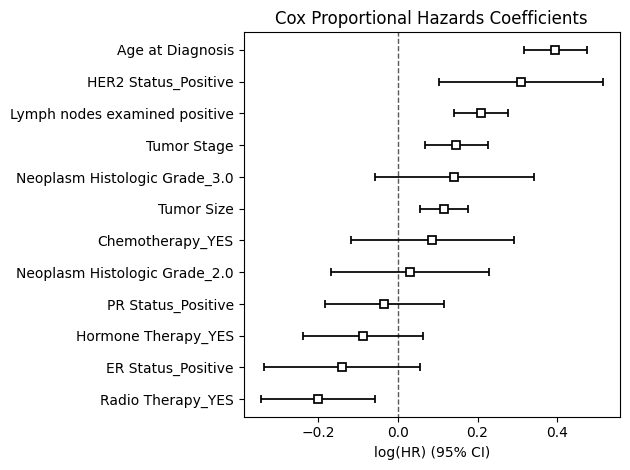

In [9]:
ax = cph.plot()
ax.set_title("Cox Proportional Hazards Coefficients")
plt.tight_layout()
plt.show()


In [10]:
cph.check_assumptions(
    model_df,
    p_value_threshold=0.05,
    show_plots=False
)


The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1354 total observations, 596 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic      p  -log2(p)
Age at Diagnosis              km             18.62 <0.005     15.94
                              rank           19.80 <0.005     16.83
Chemotherapy_YES              km              0.05   0.82      0.29
                              rank            0.05   0.82      0.28
ER Status_Positive            km              4.16   0.04      4.59
                              rank            5.58   0.02      5.79
HER2 Status_Positive          km              0.06   0.80      0.32
                              rank            0.03   0.86      0.21
Hormone Therapy_YES           km             14.57 <0.005     12.85
                              rank           16.31 <0.005     14.18
Lymph nodes examined positive km              0.13   0.72      0.48
                              rank            0.21   0.65      0.63
Neoplasm Histologic Grade_2.0 km              0.84   0.36      1.48
                              rank            1.16   0.28      1.83
Neoplasm Histologic Grade_3.0 km              2.05   0.15      2.71
                              rank            2.09   0.15      2.75
PR Status_Positive            km              2.30   0.13      2.95
                              rank            3.16   0.08      3.73
Radio Therapy_YES             km              0.14   0.71      0.50
                              rank            0.21   0.65      0.62
Tumor Size                    km              1.61   0.20      2.29
                              rank            1.78   0.18      2.46
Tumor Stage                   km             11.99 <0.005     10.87
                              rank           12.81 <0.005     11.50



1. Variable 'Age at Diagnosis' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Age at Diagnosis' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Age at Diagnosis' using pd.cut, and then specify it in
`strata=['Age at Diagnosis', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Tumor Stage' failed the non-proportional test: p-value is 0.0003.

   Advice 1: the functional form of the variable 'Tumor Stage' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D

[]

# Cox Model: Stratified Refit

In [11]:
model_df = df[[TIME_COL, "event"] + cox_features].copy()

num_cols = [
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Tumor Stage",
]

for c in num_cols:
    model_df[c] = pd.to_numeric(model_df[c], errors="coerce")

model_df = model_df.dropna()

cat_cols = [c for c in cox_features if c not in num_cols]

model_df = pd.get_dummies(
    model_df,
    columns=cat_cols,
    drop_first=True
)

for c in num_cols:
    model_df[c] = (
        model_df[c] - model_df[c].mean()
    ) / (model_df[c].std() + 1e-9)

In [12]:
from lifelines import CoxPHFitter

cph_strat = CoxPHFitter(penalizer=0.1)

cph_strat.fit(
    model_df,
    duration_col=TIME_COL,
    event_col="event",
    strata=[
        "ER Status_Positive",
        "Hormone Therapy_YES"
    ]
)

cph_strat.print_summary()

model,lifelines.CoxPHFitter
duration col,'Overall Survival (Months)'
event col,'event'
penalizer,0.1
l1 ratio,0.0
strata,"[ER Status_Positive, Hormone Therapy_YES]"
baseline estimation,breslow
number of observations,1354
number of events observed,758
partial log-likelihood,-3945.45
time fit was run,2026-01-16 01:28:20 UTC


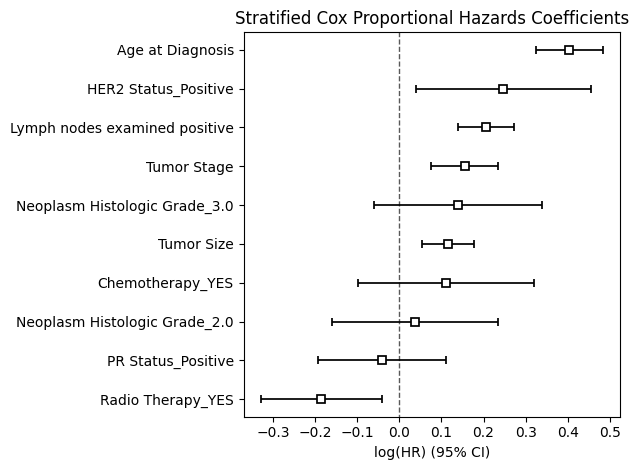

In [13]:
import matplotlib.pyplot as plt

ax = cph_strat.plot()
ax.set_title("Stratified Cox Proportional Hazards Coefficients")
plt.tight_layout()
plt.show()

In [14]:
cph_strat.check_assumptions(
    model_df,
    p_value_threshold=0.05,
    show_plots=False
)

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1354 total observations, 596 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic      p  -log2(p)
Age at Diagnosis              km             17.14 <0.005     14.81
                              rank           19.16 <0.005     16.34
Chemotherapy_YES              km              0.05   0.82      0.28
                              rank            0.81   0.37      1.44
HER2 Status_Positive          km              0.41   0.52      0.94
                              rank            0.03   0.86      0.22
Lymph nodes examined positive km              0.06   0.80      0.32
                              rank            0.62   0.43      1.21
Neoplasm Histologic Grade_2.0 km              0.92   0.34      1.57
                              rank            1.30   0.25      1.98
Neoplasm Histologic Grade_3.0 km              1.92   0.17      2.59
                              rank            0.06   0.81      0.31
PR Status_Positive            km              1.95   0.16      2.62
                              rank            1.84   0.17      2.52
Radio Therapy_YES             km              0.18   0.67      0.58
                              rank            0.00   0.97      0.05
Tumor Size                    km              1.55   0.21      2.23
                              rank            0.25   0.62      0.70
Tumor Stage                   km             10.72 <0.005      9.88
                              rank            2.04   0.15      2.71



1. Variable 'Age at Diagnosis' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Age at Diagnosis' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Age at Diagnosis' using pd.cut, and then specify it in
`strata=['Age at Diagnosis', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'Tumor Stage' failed the non-proportional test: p-value is 0.0011.

   Advice 1: the functional form of the variable 'Tumor Stage' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D

[]